## Block House Quantitative Strategist Internship 2025 Assignment

### Name: Aditya Rajendra Madkar

### ORDER FLOW IMBALANCE

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv(r"C:\Users\adity\OneDrive\Desktop\Blockhouse\first_25000_rows.csv")
data.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21T11:54:29.221064336Z,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21T11:54:29.223769812Z,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21T11:54:29.225030400Z,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21T11:54:29.712600612Z,2024-10-21T11:54:29.712434212Z,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21T11:54:29.764839221Z,2024-10-21T11:54:29.764673165Z,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


### Step 1

In [6]:
def compute_best_level_ofi(df):
    ofi_best = []
    prev_bid = prev_ask = prev_bid_size = prev_ask_size = None

    for _, row in df.iterrows():
        bid = row['bid_px_00']
        ask = row['ask_px_00']
        bid_size = row['bid_sz_00']
        ask_size = row['ask_sz_00']

        # Skip computation if any prior value is None (i.e., first iteration)
        if None in [prev_bid, prev_ask, prev_bid_size, prev_ask_size]:
            ofi_best.append(0)
        else:
            bid_contrib = (
                bid_size if bid > prev_bid else
                (bid_size - prev_bid_size if bid == prev_bid else -prev_bid_size)
            )
            ask_contrib = (
                -ask_size if ask < prev_ask else
                (prev_ask_size - ask_size if ask == prev_ask else prev_ask_size)
            )
            ofi_best.append(bid_contrib + ask_contrib)

        # Update previous values
        prev_bid, prev_ask = bid, ask
        prev_bid_size, prev_ask_size = bid_size, ask_size

    df['OFI_best'] = ofi_best
    return df


### Step 2

In [8]:
def compute_multi_level_ofi(df, levels=10):
    multi_ofi = []
    prev = {f'bid_px_{i:02}': None for i in range(levels)}
    prev.update({f'ask_px_{i:02}': None for i in range(levels)})
    prev.update({f'bid_sz_{i:02}': None for i in range(levels)})
    prev.update({f'ask_sz_{i:02}': None for i in range(levels)})

    for _, row in df.iterrows():
        total_ofi = 0
        for i in range(levels):
            bpx = row[f'bid_px_{i:02}']
            bs = row[f'bid_sz_{i:02}']
            apx = row[f'ask_px_{i:02}']
            asp = row[f'ask_sz_{i:02}']

            if prev[f'bid_px_{i:02}'] is not None:
                total_ofi += (
                    bs if bpx > prev[f'bid_px_{i:02}'] else
                    (bs - prev[f'bid_sz_{i:02}'] if bpx == prev[f'bid_px_{i:02}'] else -prev[f'bid_sz_{i:02}'])
                )

            if prev[f'ask_px_{i:02}'] is not None:
                total_ofi += (
                    -asp if apx < prev[f'ask_px_{i:02}'] else
                    (prev[f'ask_sz_{i:02}'] - asp if apx == prev[f'ask_px_{i:02}'] else prev[f'ask_sz_{i:02}'])
                )

            prev[f'bid_px_{i:02}'], prev[f'bid_sz_{i:02}'] = bpx, bs
            prev[f'ask_px_{i:02}'], prev[f'ask_sz_{i:02}'] = apx, asp

        multi_ofi.append(total_ofi)

    df['OFI_multi'] = multi_ofi
    return df


### Step 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def compute_integrated_ofi(df, levels=10):
    ofi_levels = []
    for i in range(levels):
        ofi = df[f'bid_sz_{i:02}'] - df[f'ask_sz_{i:02}']
        ofi_levels.append(ofi)

    ofi_matrix = np.array(ofi_levels).T
    scaled = StandardScaler().fit_transform(ofi_matrix)

    pca = PCA(n_components=1)
    integrated = pca.fit_transform(scaled)

    df['OFI_integrated'] = integrated.flatten()
    return df


### Step 4

In [12]:
def compute_cross_asset_ofi(df):
    df['OFI_cross'] = df.groupby('ts_event')['OFI_best'].transform(lambda x: x.mean())
    return df

### Step 5

In [14]:
data = compute_best_level_ofi(data)
data = compute_multi_level_ofi(data)
data = compute_integrated_ofi(data)
data = compute_cross_asset_ofi(data)


### Output

In [38]:
data[['ts_event', 'OFI_best', 'OFI_multi', 'OFI_integrated', 'OFI_cross']].head(10)

,ts_event,OFI_best,OFI_multi,OFI_integrated,OFI_cross
0,2024-10-21 11:54:29.221064336+00:00,0,0,-0.260270,0.0
1,2024-10-21 11:54:29.223769812+00:00,2,2,-0.260288,2.0
2,2024-10-21 11:54:29.225030400+00:00,3,3,-0.260315,3.0
3,2024-10-21 11:54:29.712434212+00:00,0,200,-0.387821,0.0
4,2024-10-21 11:54:29.764673165+00:00,0,-200,-0.260315,0.0
5,2024-10-21 11:54:29.764685027+00:00,0,410,-0.086469,0.0
6,2024-10-21 11:54:36.289427977+00:00,0,-599,-0.030784,0.0
7,2024-10-21 11:54:37.990793976+00:00,-200,-200,-0.030784,-200.0
8,2024-10-21 11:54:39.124291588+00:00,200,1012,-0.085781,200.0
9,2024-10-21 11:54:39.134140341+00:00,-200,-1012,-0.030784,-200.0


### PLOT

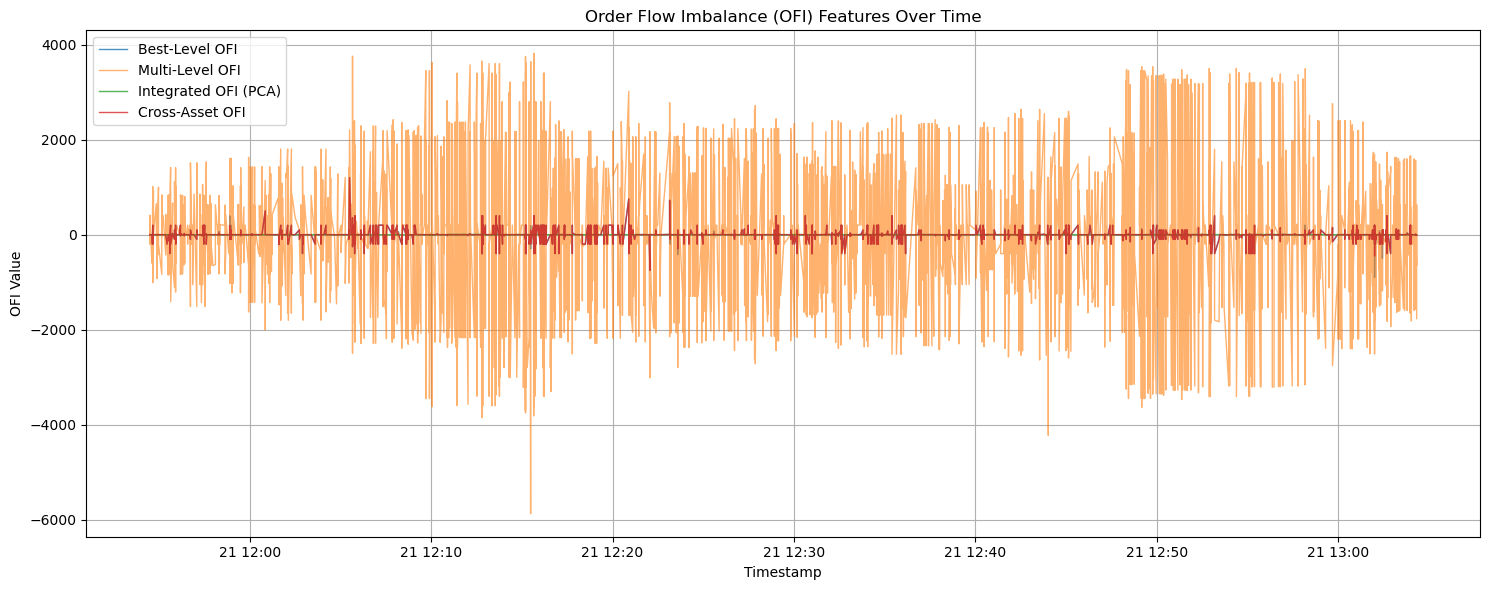

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure timestamp column is datetime
data['ts_event'] = pd.to_datetime(data['ts_event'])
data = data.sort_values('ts_event')

# Plot all OFI features
plt.figure(figsize=(15, 6))

plt.plot(data['ts_event'], data['OFI_best'], label='Best-Level OFI', alpha=0.8, linewidth=1)
plt.plot(data['ts_event'], data['OFI_multi'], label='Multi-Level OFI', alpha=0.6, linewidth=1)
plt.plot(data['ts_event'], data['OFI_integrated'], label='Integrated OFI (PCA)', alpha=0.8, linewidth=1)
plt.plot(data['ts_event'], data['OFI_cross'], label='Cross-Asset OFI', alpha=0.8, linewidth=1)

plt.title("Order Flow Imbalance (OFI) Features Over Time")
plt.xlabel("Timestamp")
plt.ylabel("OFI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---